<a href="https://colab.research.google.com/github/christiano1974/portifolios-trabalho/blob/master/C%C3%B3pia_de_soja_exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##### Este é um programa de machine learning de árvore de decisão
####  programa foi aplicado para a identificaça de doenças em relação a soja.
### 19 doenças (atributos - variáveis regressoras) e 1 classe (variável resposta)
### programa realizado em 02/11/2021. autor: Christiano.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier 
import graphviz
from sklearn.tree import export_graphviz
from yellowbrick.classifier import ConfusionMatrix

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.metrics.classification module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.metrics. Anything that cannot be imported from sklearn.metrics is now part of the private API.
  warnings.warn(message, FutureWarning)


In [ ]:
soja = pd.read_csv('soybean.csv',sep=',')

In [ ]:
soja.shape

(683, 36)

In [ ]:
soja.head()

,date,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,plant-growth,leaves,leafspots-halo,leafspots-marg,leafspot-size,leaf-shread,leaf-malf,leaf-mild,stem,lodging,stem-cankers,canker-lesion,fruiting-bodies,external-decay,mycelium,int-discolor,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
0,october,normal,gt-norm,norm,yes,same-lst-yr,low-areas,pot-severe,none,90-100,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,no,above-sec-nde,brown,present,firm-and-dry,absent,none,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
1,august,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,severe,fungicide,80-89,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,brown,present,firm-and-dry,absent,none,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
2,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,fungicide,lt-80,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,dna,present,firm-and-dry,absent,none,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
3,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,none,80-89,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,dna,present,firm-and-dry,absent,none,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
4,october,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,pot-severe,none,lt-80,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,brown,present,firm-and-dry,absent,none,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker


In [ ]:
classe = soja.iloc[:,35].values
previsores = soja.iloc[:,0:35].values

In [ ]:
labelencoder = LabelEncoder()
for k in range(0,35):
  previsores[:,k] = labelencoder.fit_transform(previsores[:,k])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(previsores, classe,test_size = 0.3,random_state=0)

In [ ]:
arvore = DecisionTreeClassifier()
arvore.fit(X_train,y_train)
export_graphviz(arvore,out_file='tree.dot')

In [ ]:

arvore

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [ ]:
previsoes = arvore.predict(X_test)
previsoes

array(['brown-spot', 'phytophthora-rot', 'herbicide-injury',
       'purple-seed-stain', 'cyst-nematode', 'bacterial-blight',
       'brown-stem-rot', 'bacterial-pustule', 'brown-spot',
       'alternarialeaf-spot', 'charcoal-rot', 'bacterial-blight',
       'anthracnose', 'anthracnose', 'alternarialeaf-spot', 'brown-spot',
       'alternarialeaf-spot', 'alternarialeaf-spot',
       'rhizoctonia-root-rot', 'phytophthora-rot', 'anthracnose',
       'brown-stem-rot', 'brown-spot', 'phyllosticta-leaf-spot',
       'diaporthe-stem-canker', 'brown-spot', 'anthracnose',
       'diaporthe-stem-canker', 'downy-mildew', 'phytophthora-rot',
       'frog-eye-leaf-spot', 'alternarialeaf-spot',
       'phyllosticta-leaf-spot', 'brown-spot', 'brown-spot',
       'bacterial-pustule', 'brown-stem-rot', 'charcoal-rot',
       'brown-spot', 'brown-spot', 'brown-stem-rot',
       'alternarialeaf-spot', 'phytophthora-rot', 'anthracnose',
       'bacterial-pustule', '2-4-d-injury', 'frog-eye-leaf-spot',
  

In [ ]:
confusao = confusion_matrix(y_test,previsoes)
confusao

array([[ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0, 25,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,
         0,  0,  0],
       [ 0,  0, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  1,  0],
       [ 0,  0,  0,  5,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  1,  0],
       [ 0,  0,  0,  0,  6,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0, 21,  0,  0,  0,  0,  0,  0,  1,  0,  1,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  5,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  6,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  0,  0,  0,  0,  0

In [ ]:
taxa_acerto = accuracy_score(y_test,previsoes)
print('taxa de acerto: %5.3f\n'% taxa_acerto)
print('----------------\n')
taxa_erro = 1 - taxa_acerto
print('taxa de erro: %5.3f\n'% taxa_erro)

taxa de acerto: 0.902

----------------

taxa de erro: 0.098



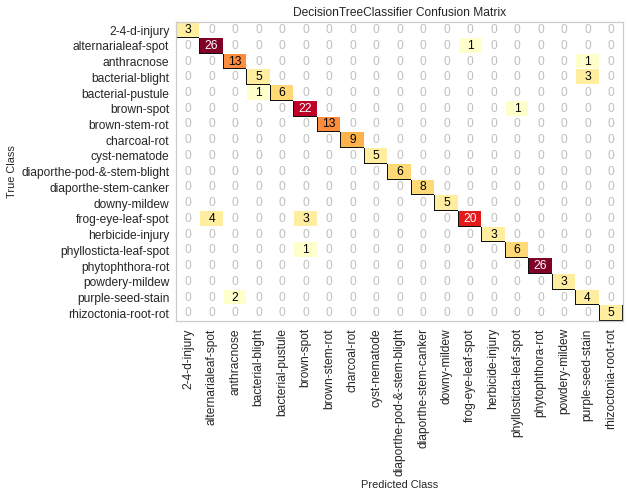

In [ ]:
v = ConfusionMatrix(DecisionTreeClassifier())
v.fit(X_train,y_train)
v.score(X_test,y_test)
v.poof()

In [ ]:
print(y_test[3])
print("\n")
print(previsoes[3])

purple-seed-stain


purple-seed-stain


In [ ]:
verificacoes = pd.DataFrame()
verificacoes['dados reais'] = y_test
verificacoes['dados preditos'] = previsoes
lista = []
for t in range (0,205):
  if y_test[t] == previsoes[t]:
    lista.append('acerto')
  else:
    lista.append('erro')
verificacoes['acertos/erros'] = lista
verificacoes

,dados reais,dados preditos,acertos/erros
0,brown-spot,brown-spot,acerto
1,phytophthora-rot,phytophthora-rot,acerto
2,herbicide-injury,herbicide-injury,acerto
3,purple-seed-stain,purple-seed-stain,acerto
4,cyst-nematode,cyst-nematode,acerto
...,...,...,...
200,anthracnose,anthracnose,acerto
201,diaporthe-pod-&-stem-blight,diaporthe-pod-&-stem-blight,acerto
202,purple-seed-stain,purple-seed-stain,acerto
203,bacterial-pustule,bacterial-pustule,acerto


In [ ]:
verificacoes['acertos/erros'].unique()

array(['acerto', 'erro'], dtype=object)

In [ ]:
verificacoes['acertos/erros'].value_counts()

acerto    185
erro       20
Name: acertos/erros, dtype: int64